In [1]:
import os

print(os.listdir("/content"))

['.config', 'brain_tumor_dataset.zip', '.ipynb_checkpoints', 'sample_data']


In [3]:
import os

print(os.listdir("/content"))

['.config', 'brain_tumor_dataset.zip', '.ipynb_checkpoints', 'sample_data']


In [4]:
import zipfile

zip_path = "/content/brain_tumor_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

print(os.listdir("/content"))

['.config', 'brain_tumor_dataset.zip', 'brain_tumor_dataset', '.ipynb_checkpoints', 'sample_data']


In [6]:
import os

print(os.listdir("/content/brain_tumor_dataset"))

['yes', 'no']


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/brain_tumor_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/brain_tumor_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [9]:
class_names = train_ds.class_names
print(class_names)

['no', 'yes']


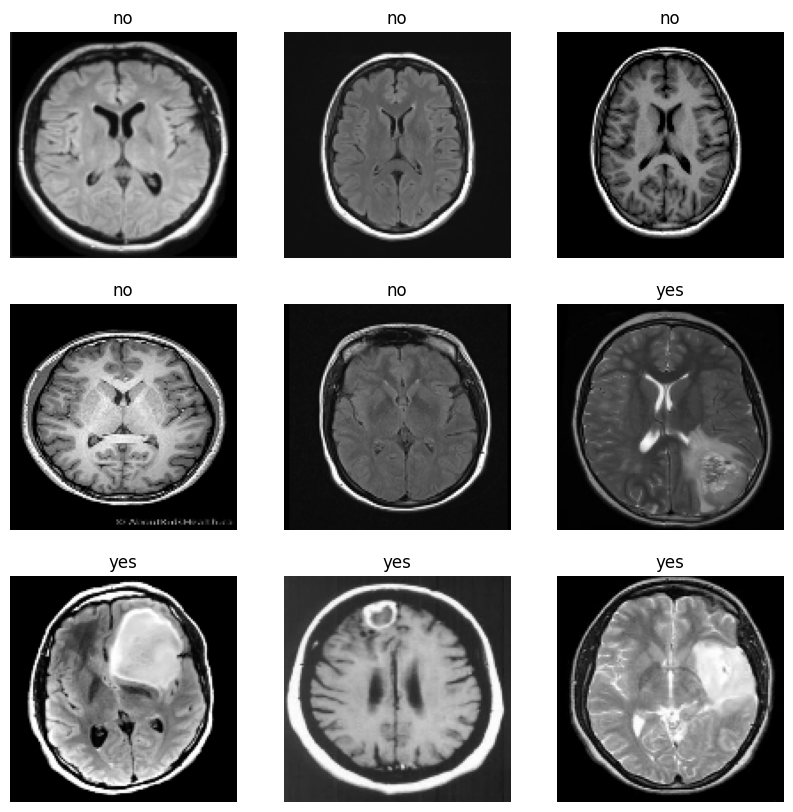

In [10]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [12]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 992ms/step - accuracy: 0.6502 - loss: 0.6487 - val_accuracy: 0.7200 - val_loss: 0.5415
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7882 - loss: 0.4982 - val_accuracy: 0.7200 - val_loss: 0.6005
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7783 - loss: 0.5130 - val_accuracy: 0.7400 - val_loss: 0.5357
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 941ms/step - accuracy: 0.8079 - loss: 0.4528 - val_accuracy: 0.8000 - val_loss: 0.5096
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8325 - loss: 0.4203 - val_accuracy: 0.8000 - val_loss: 0.4944
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8571 - loss: 0.3615 - val_accuracy: 0.7800 - val_loss: 0.4824
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8867 - loss: 0.3126 - val_accuracy: 0.7400 - val_loss: 0.5277
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8818 - loss: 0.2867 - val_accuracy: 0.8000 - val_loss: 0.4539
Epoch 9/

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9507 - loss: 0.1441 - val_accuracy: 0.8200 - val_loss: 0.3953
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 886ms/step - accuracy: 0.9803 - loss: 0.0836 - val_accuracy: 0.8600 - val_loss: 0.3231
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9754 - loss: 0.0711 - val_accuracy: 0.8200 - val_loss: 0.4472
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 896ms/step - accuracy: 0.9852 - loss: 0.0632 - val_accuracy: 0.8200 - val_loss: 0.6220
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9852 - loss: 0.0751 - val_accuracy: 0.8400 - val_loss: 0.3974
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 882ms/step - accuracy: 0.9803 - loss: 0.0593 - val_accuracy: 0.8200 - val_loss: 0.4125
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 1.0000 - loss: 0.0160 - val_accuracy: 0.8600 - val_loss: 0.4394
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 927ms/step - accuracy: 1.0000 - loss: 0.0191 - val_accuracy: 0.8600 - val_loss: 0.4864
Epoc

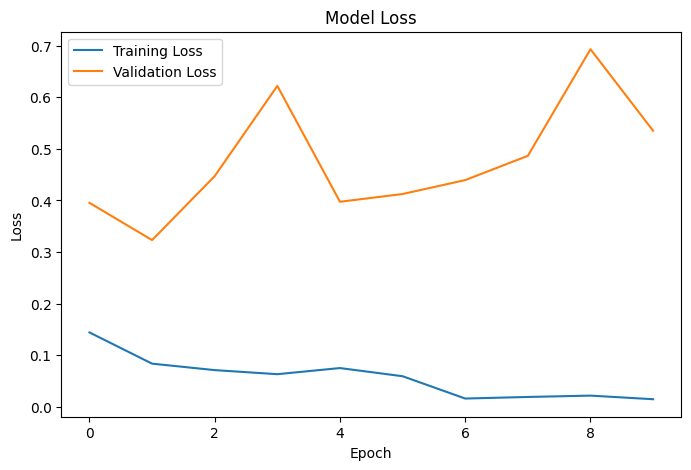

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [17]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8200 - loss: 0.5351
Validation Accuracy: 0.8199999928474426
Validation Loss: 0.5351450443267822


In [18]:
model.save("model.keras")
print("Model saved successfully!")

Model saved successfully!


In [19]:
import os

print(os.listdir("/content/brain_tumor_dataset/yes")[:10])

['Y26.jpg', 'Y42.jpg', 'Y13.jpg', 'Y166.JPG', 'Y153.jpg', 'Y90.jpg', 'Y78.jpg', 'Y96.jpg', 'Y195.JPG', 'Y257.jpg']


In [20]:
img = tf.keras.utils.load_img(
    "/content/brain_tumor_dataset/yes/Y1.jpg",
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) / 255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Tumor Detected")
else:
    print("Prediction: No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
Prediction: Tumor Detected
